In [5]:
from Bio import SeqIO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
record = SeqIO.read("sequence.fasta", "fasta")
sequence = str(record.seq).upper()
print("Genome ID:", record.id)
print("Genome length:", len(sequence), "bp")

Genome ID: NC_000913.3
Genome length: 4641652 bp


In [7]:
print("First 100 bases:")
print(sequence[:1000])
print("\nLast 100 bases:")
print(sequence[-100:])

First 100 bases:
AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGCTTCTGAACTGGTTACCTGCCGTGAGTAAATTAAAATTTTATTGACTTAGGTCACTAAATACTTTAACCAATATAGGCATAGCGCACAGACAGATAAAAATTACAGAGTACACAACATCCATGAAACGCATTAGCACCACCATTACCACCACCATCACCATTACCACAGGTAACGGTGCGGGCTGACGCGTACAGGAAACACAGAAAAAAGCCCGCACCTGACAGTGCGGGCTTTTTTTTTCGACCAAAGGTAACGAGGTAACAACCATGCGAGTGTTGAAGTTCGGCGGTACATCAGTGGCAAATGCAGAACGTTTTCTGCGTGTTGCCGATATTCTGGAAAGCAATGCCAGGCAGGGGCAGGTGGCCACCGTCCTCTCTGCCCCCGCCAAAATCACCAACCACCTGGTGGCGATGATTGAAAAAACCATTAGCGGCCAGGATGCTTTACCCAATATCAGCGATGCCGAACGTATTTTTGCCGAACTTTTGACGGGACTCGCCGCCGCCCAGCCGGGGTTCCCGCTGGCGCAATTGAAAACTTTCGTCGATCAGGAATTTGCCCAAATAAAACATGTCCTGCATGGCATTAGTTTGTTGGGGCAGTGCCCGGATAGCATCAACGCTGCGCTGATTTGCCGTGGCGAGAAAATGTCGATCGCCATTATGGCCGGCGTATTAGAAGCGCGCGGTCACAACGTTACTGTTATCGATCCGGTCGAAAAACTGCTGGCAGTGGGGCATTACCTCGAATCTACCGTCGATATTGCTGAGTCCACCCGCCGTATTGCGGCAAGCCGCATTCCGGCTGATCACATGGTGCTGATGGCAGGTTTCACCGCCGGTAATGAAAAAGGCGAACTGGTGGTGCTTGGACGCAACGGTTCCGACTACTCTGCTGCGGTGCTGGCTGC

In [9]:
#Genome statistics

from collections import Counter

counts = Counter(sequence)
A = counts["A"]
T = counts["T"]
G = counts["G"]
C = counts["C"]

genome_length = len(sequence)
AT_content = ((A + T) / genome_length) * 100
GC_content = ((G + C) / genome_length) * 100

print("Genome length:", genome_length, "bp")
print("A:", A)
print("T:", T)
print("G:", G)
print("C:", C)
print(f"AT content: {AT_content:.2f}%")
print(f"GC content: {GC_content:.2f}%")


Genome length: 4641652 bp
A: 1142742
T: 1141382
G: 1177437
C: 1180091
AT content: 49.21%
GC content: 50.79%


In [10]:
#Sliding window GC analysis

window_size = 1000
step_size = 100

results = []

for start in range(0, len(sequence) - window_size + 1, step_size):
    window = sequence[start:start + window_size]
    gc = (window.count("G") + window.count("C")) / len(window) * 100
    at = (window.count("A") + window.count("T")) / len(window) * 100

    results.append({
        "Start": start + 1,
        "End": start + window_size,
        "GC_percent": gc,
        "AT_percent": at,
        "AT_GC_ratio": at / gc if gc != 0 else np.nan})

gc_df = pd.DataFrame(results)
gc_df.head()

,Start,End,GC_percent,AT_percent,AT_GC_ratio
0,1,1000,50.7,49.3,0.972387
1,101,1100,52.3,47.7,0.912046
2,201,1200,54.3,45.7,0.841621
3,301,1300,53.6,46.4,0.865672
4,401,1400,54.9,45.1,0.821494


In [11]:
#Statistical summary

summary = pd.DataFrame({
    "Statistic": [
        "Number of windows",
        "Mean GC (%)",
        "Median GC (%)",
        "Minimum GC (%)",
        "Maximum GC (%)",
        "Standard deviation GC (%)",
        "Mean AT (%)",
        "Mean AT/GC ratio"
    ],
    "Value": [
        len(gc_df),
        gc_df["GC_percent"].mean(),
        gc_df["GC_percent"].median(),
        gc_df["GC_percent"].min(),
        gc_df["GC_percent"].max(),
        gc_df["GC_percent"].std(),
        gc_df["AT_percent"].mean(),
        gc_df["AT_GC_ratio"].mean()]})

summary

,Statistic,Value
0,Number of windows,46407.000000
1,Mean GC (%),50.791480
2,Median GC (%),51.600000
3,Minimum GC (%),27.400000
4,Maximum GC (%),69.900000
5,Standard deviation GC (%),4.779437
6,Mean AT (%),49.208520
7,Mean AT/GC ratio,0.989004


In [16]:
# Saving table and Statistical summary

# Create results folder
import os

os.makedirs("results", exist_ok=True)

# Save sliding-window analysis
gc_df.to_csv("GC_sliding_window_analysis.csv", index=False)

# Save statistical summary
summary.to_csv("gc_statistical_summary.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


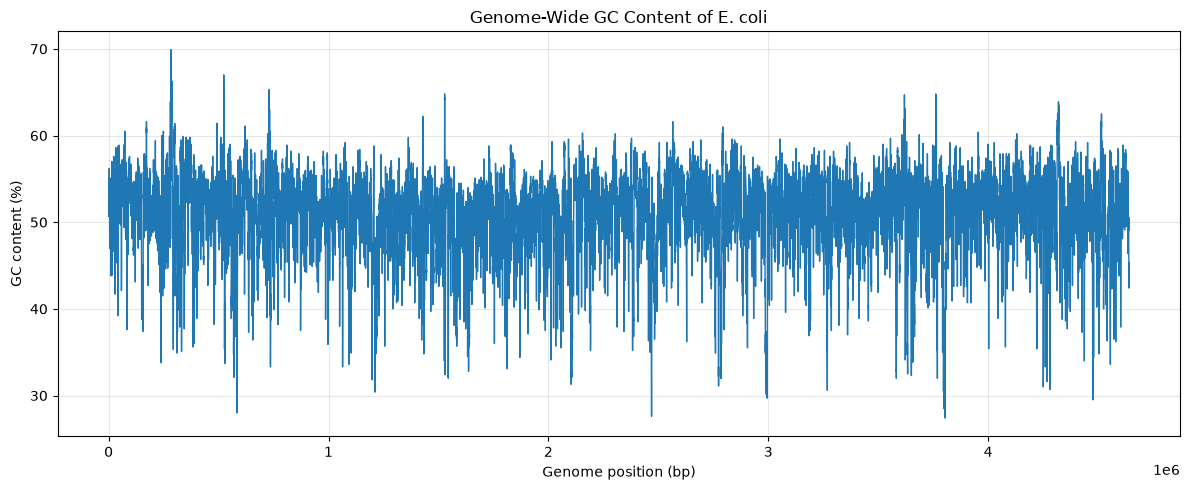

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(
    gc_df["Start"],
    gc_df["GC_percent"],
    linewidth=1
)

plt.xlabel("Genome position (bp)")
plt.ylabel("GC content (%)")
plt.title("Genome-Wide GC Content of E. coli")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Genome_wide_gc_content.png", dpi=300)
plt.show()


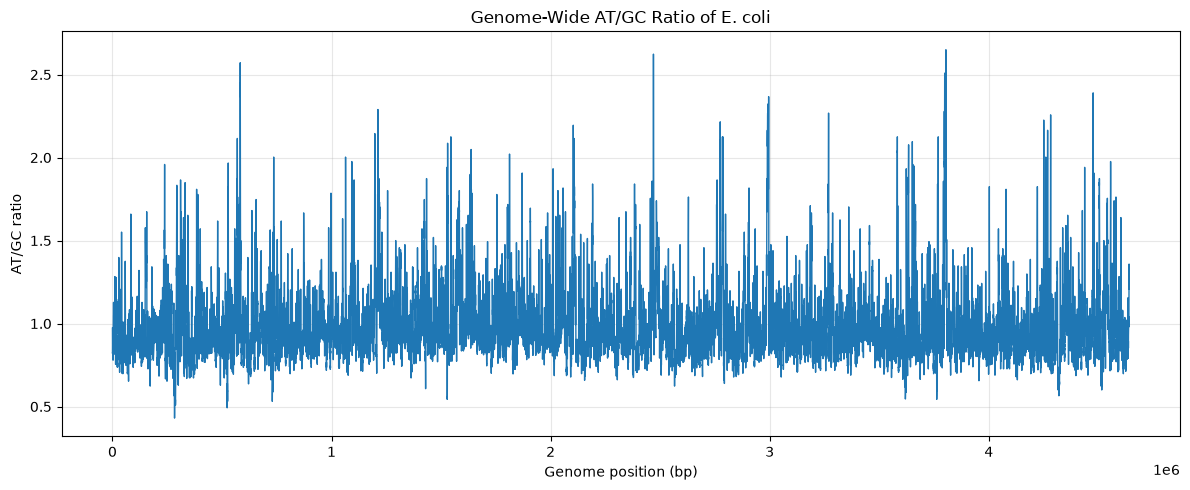

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(
    gc_df["Start"],
    gc_df["AT_GC_ratio"],
    linewidth=1
)

plt.xlabel("Genome position (bp)")
plt.ylabel("AT/GC ratio")
plt.title("Genome-Wide AT/GC Ratio of E. coli")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("at_gc_ratio.png", dpi=300)
plt.show()

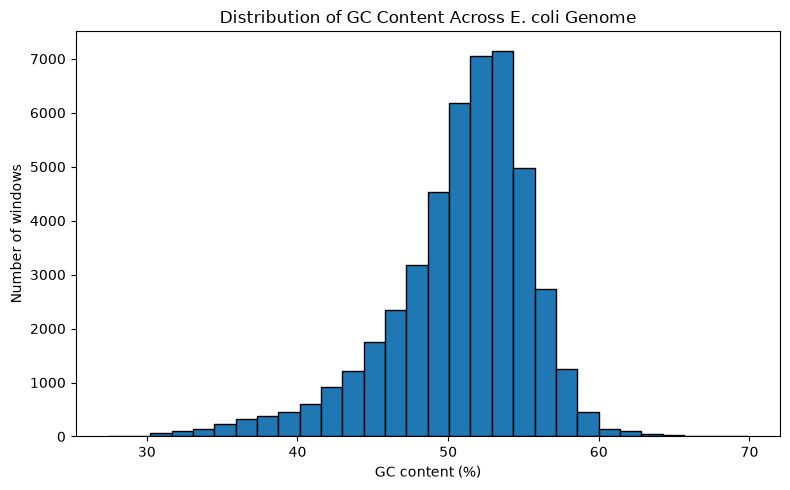

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    gc_df["GC_percent"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("GC content (%)")
plt.ylabel("Number of windows")
plt.title("Distribution of GC Content Across E. coli Genome")

plt.tight_layout()
plt.savefig("gc_content_histogram.png", dpi=300)
plt.show()

In [18]:
#saving genome composition
composition = pd.DataFrame({
    "Nucleotide": ["A", "T", "G", "C"],
    "Count": [A, T, G, C],
    "Percentage": [
        A / genome_length * 100,
        T / genome_length * 100,
        G / genome_length * 100,
        C / genome_length * 100]})

composition.to_csv("nucleotide_composition.csv", index=False)
composition

,Nucleotide,Count,Percentage
0,A,1142742,24.619295
1,T,1141382,24.589995
2,G,1177437,25.366766
3,C,1180091,25.423944


In [21]:
print(summary.to_string(index=False))

                Statistic        Value
        Number of windows 46407.000000
              Mean GC (%)    50.791480
            Median GC (%)    51.600000
           Minimum GC (%)    27.400000
           Maximum GC (%)    69.900000
Standard deviation GC (%)     4.779437
              Mean AT (%)    49.208520
         Mean AT/GC ratio     0.989004


In [20]:
print(composition.to_string(index=False))

Nucleotide   Count  Percentage
         A 1142742   24.619295
         T 1141382   24.589995
         G 1177437   25.366766
         C 1180091   25.423944
